# 1. DrugBank Dataset

In [1]:
import os

def find_project_root(marker="data"):
    path = os.getcwd()
    while True:
        if marker in os.listdir(path):
            return path
        parent = os.path.dirname(path)
        if parent == path:
            raise FileNotFoundError("Project root not found")
        path = parent

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

print("Project root:", PROJECT_ROOT)



Project root: C:\Users\Srija Paul Chowdhury\drug_repositioning_gnn


In [2]:
import os
import xml.etree.ElementTree as ET
import pandas as pd
from tqdm import tqdm


In [3]:
xml_path = "data/raw/DrugBank_data.xml"

rows = []

context = ET.iterparse(xml_path, events=("end",))

print("Streaming XML... This will take time but will not crash.")

for event, elem in tqdm(context):

    if elem.tag.endswith("drug"):
        
        drug_id = None
        drug_name = None
        
        for child in elem:
            if child.tag.endswith("drugbank-id") and drug_id is None:
                drug_id = child.text
            if child.tag.endswith("name") and drug_name is None:
                drug_name = child.text

            if child.tag.endswith("targets"):
                for target in child:
                    for tchild in target:
                        if tchild.tag.endswith("polypeptide"):
                            protein_id = tchild.attrib.get("id")
                            if protein_id:
                                rows.append([drug_id, drug_name, protein_id])

        elem.clear()  # important to free memory

print("Parsing complete ✔")



Streaming XML... This will take time but will not crash.


36207430it [03:02, 198222.42it/s]

Parsing complete ✔


In [4]:
df = pd.DataFrame(rows, columns=[
    "drug_id",
    "drug_name",
    "protein_id"
])

print("Total extracted rows =", len(df))
df.head()

Total extracted rows = 27338


,drug_id,drug_name,protein_id
0,DB00001,Lepirudin,P00734
1,DB00002,Cetuximab,P00533
2,DB00002,Cetuximab,O75015
3,DB00002,Cetuximab,P02745
4,DB00002,Cetuximab,P02746


In [5]:
print("Before cleaning:", len(df))

df = df.dropna()
df = df.drop_duplicates()

print("After cleaning:", len(df))


Before cleaning: 27338
After cleaning: 26766


In [6]:
print("Unique Drugs:", df["drug_id"].nunique())
print("Unique Proteins:", df["protein_id"].nunique())


Unique Drugs: 9875
Unique Proteins: 5096


### 1.1 Proteins per Drug Distribution Graph


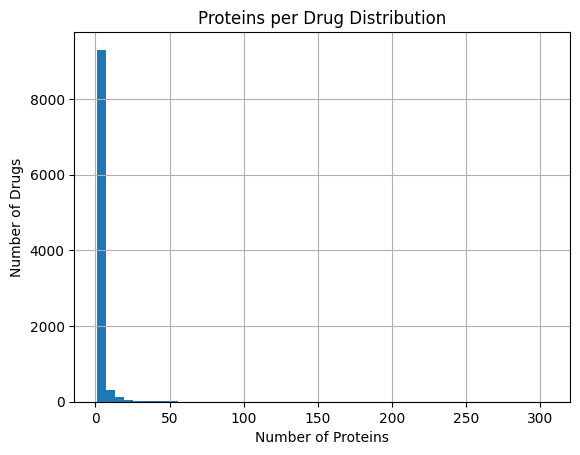

In [7]:
import matplotlib.pyplot as plt

counts = df.groupby("drug_id")["protein_id"].count()

plt.figure()
counts.hist(bins=50)
plt.title("Proteins per Drug Distribution")
plt.xlabel("Number of Proteins")
plt.ylabel("Number of Drugs")
plt.show()


# 2. String Dataset

In [33]:
string_path = "data/raw/9606.protein.links.v12.0.txt"

string_df = pd.read_csv(string_path, sep=" ")

print("Total raw interactions:", len(string_df))
string_df.head()


Total raw interactions: 13715404


,protein1,protein2,combined_score
0,9606.ENSP00000000233,9606.ENSP00000356607,173
1,9606.ENSP00000000233,9606.ENSP00000427567,154
2,9606.ENSP00000000233,9606.ENSP00000253413,151
3,9606.ENSP00000000233,9606.ENSP00000493357,471
4,9606.ENSP00000000233,9606.ENSP00000324127,201


In [34]:
print(string_df["combined_score"].describe())



count    1.371540e+07
mean     2.686240e+02
std      1.569828e+02
min      1.500000e+02
25%      1.710000e+02
50%      2.090000e+02
75%      2.980000e+02
max      9.990000e+02
Name: combined_score, dtype: float64


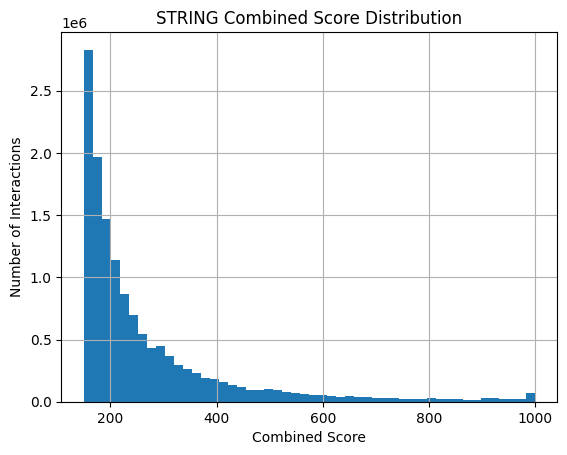

In [35]:
import matplotlib.pyplot as plt

plt.figure()
string_df["combined_score"].hist(bins=50)
plt.title("STRING Combined Score Distribution")
plt.xlabel("Combined Score")
plt.ylabel("Number of Interactions")
plt.show()


In [43]:
print("Before filtering:", len(string_df))

string_filtered = string_df[string_df["combined_score"] >= 700].copy()


print("After filtering:", len(string_filtered))





Before filtering: 13715404
After filtering: 473860


In [44]:
unique_proteins = pd.concat([
    string_filtered["protein1"],
    string_filtered["protein2"]
]).nunique()

print("Unique proteins in filtered STRING:", unique_proteins)


Unique proteins in filtered STRING: 16201


Total nodes: 16201


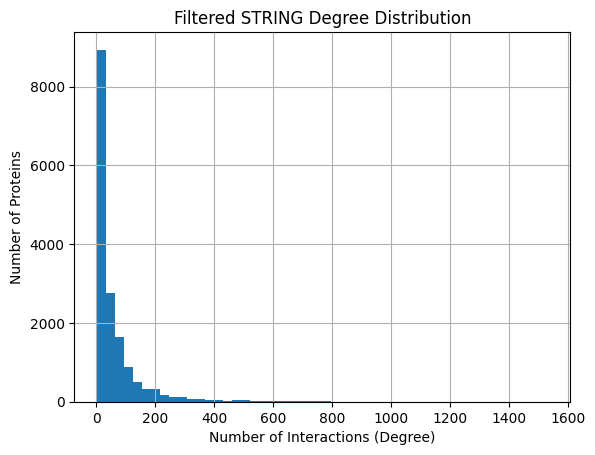

In [45]:
import matplotlib.pyplot as plt

# Compute degree
degree_counts = pd.concat([
    string_filtered["protein1"],
    string_filtered["protein2"]
]).value_counts()

print("Total nodes:", len(degree_counts))

plt.figure()
degree_counts.hist(bins=50)
plt.title("Filtered STRING Degree Distribution")
plt.xlabel("Number of Interactions (Degree)")
plt.ylabel("Number of Proteins")
plt.show()



In [46]:
alias_path = "data/raw/9606.protein.aliases.v12.0.txt"

alias_df = pd.read_csv(alias_path, sep="\t")

print("Alias rows:", len(alias_df))
alias_df.head()


Alias rows: 3889207


,#string_protein_id,alias,source
0,9606.ENSP00000000233,2B6H,Ensembl_PDB
1,9606.ENSP00000000233,2B6H,UniProt_DR_PDB
2,9606.ENSP00000000233,381,Ensembl_HGNC_entrez_id
3,9606.ENSP00000000233,381,KEGG_GENEID
4,9606.ENSP00000000233,381,KEGG_KEGGID_SHORT


In [47]:

uniprot_alias = alias_df[alias_df["source"] == "Ensembl_UniProt"]

print("Mappings:", len(uniprot_alias))
uniprot_alias.head()



Mappings: 96363


,#string_protein_id,alias,source
6,9606.ENSP00000000233,A4D0Z3,Ensembl_UniProt
25,9606.ENSP00000000233,ARF5,Ensembl_UniProt
40,9606.ENSP00000000233,C9J1Z8,Ensembl_UniProt
85,9606.ENSP00000000233,P84085,Ensembl_UniProt
204,9606.ENSP00000000412,F5GX30,Ensembl_UniProt


In [48]:
ens_to_uniprot = dict(
    zip(
        uniprot_alias["#string_protein_id"],
        uniprot_alias["alias"]
    )
)

print("Dictionary size:", len(ens_to_uniprot))



Dictionary size: 19638


In [49]:
string_filtered["protein1_uniprot"] = string_filtered["protein1"].map(ens_to_uniprot)
string_filtered["protein2_uniprot"] = string_filtered["protein2"].map(ens_to_uniprot)

print("Mapping done")



Mapping done


In [50]:
print("Before removing unmapped:", len(string_filtered))

string_mapped = string_filtered.dropna(subset=["protein1_uniprot", "protein2_uniprot"])

print("After removing unmapped:", len(string_mapped))


Before removing unmapped: 473860
After removing unmapped: 472588


In [51]:
# Keep only UniProt columns
ppi_df = string_mapped[["protein1_uniprot", "protein2_uniprot"]].copy()

ppi_df.columns = ["protein1", "protein2"]

print("Final PPI edges:", len(ppi_df))
ppi_df.head()


Final PPI edges: 472588


,protein1,protein2
85,P84085,Q15027
130,P84085,P53621
160,P84085,X6RFI8
197,P84085,P35606
268,P84085,O14579


In [52]:
ppi_df.to_csv("data/interim/protein_protein_edges.csv", index=False)

print("PPI layer saved successfully ✔")


PPI layer saved successfully ✔
